In [1]:
import tinygp
from tinygp import kernels
import jax
import jax.numpy as jnp
from tinygp.helpers import JAXArray

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import optax

In [26]:
class SpectralMixture(tinygp.kernels.Kernel):
    weight: jax.Array
    scale: jax.Array
    freq: jax.Array

    def evaluate(self, X1, X2):
        tau = jnp.atleast_1d(jnp.abs(X1 - X2))[..., None]
        return jnp.sum(
            self.weight
            * jnp.prod(
                jnp.exp(-2 * jnp.pi**2 * tau**2 / self.scale**2)
                * jnp.cos(2 * jnp.pi * self.freq * tau),
                axis=0,
            )
        )

In [15]:
class AR1(tinygp.kernels.Kernel):
    log_rho: JAXArray | float | None = None
    log_sigma: JAXArray | float | None = None

    def __check_init__(self):
        if self.log_rho is None:
            raise ValueError("Missing required argument 'log_rho'")
        if self.log_sigma is None:
            raise ValueError("Missing required argument 'log_sigma'")

    def evaluate(self, T1, T2):
        tau = jnp.abs(T1-T2)
        rho = jnp.exp(self.log_rho)
        return (jnp.square(jnp.exp(self.log_sigma)) / (1-jnp.square(rho))) * rho**tau

In [20]:
def build_gp(theta):
#     kernel = SpectralMixture(
#         jnp.exp(theta["log_weight"]),
#         jnp.exp(theta["log_scale"]),
#         jnp.exp(theta["log_freq"]),
#     )
    kernel = AR1(
        log_rho=theta["log_rho"],
        log_sigma=theta["log_sigma"],
    )
    return tinygp.GaussianProcess(
        kernel, t, mean=theta["mean"]
    )

In [27]:
params_SM = {
    "log_weight": np.log([1.0, 1.0]),
    "log_scale": np.log([10.0, 20.0]),
    "log_freq": np.log([1.0, 1.0 / 2.0]),
    "log_diag": np.log(0.1),
    "mean": 0.0,
}

In [35]:
params = {
    "log_rho": np.log(0.74),
    "log_sigma": np.log(1.0),
    "log_diag": np.log(0.1),
    "mean": 0.0,
}

In [36]:
 kernel = AR1(
    log_rho=params["log_rho"],
    log_sigma=params["log_sigma"],
)

In [37]:
kernel.evaluate(t[0],t[1])

Array(2.0811634, dtype=float32)

In [32]:
tau = jnp.abs(t[0]-t[1])
rho = jnp.exp(params["log_rho"])
(jnp.square(jnp.exp(params["log_sigma"])) / (1-jnp.square(rho))) * rho**tau

Array([2.0811634], dtype=float32)

In [34]:
rho

Array([0.74], dtype=float32)

In [30]:
 kernel_SM = SpectralMixture(
     jnp.exp(params_SM["log_weight"]),
     jnp.exp(params_SM["log_scale"]),
     jnp.exp(params_SM["log_freq"]),
 )

In [31]:
kernel_SM.evaluate(t[0],t[1])

Array(1.1129544, dtype=float32)

In [38]:
rng = np.random.default_rng(42)
t = np.sort(rng.uniform(0, 10, 50))
true_gp = build_gp(params)
y = true_gp.sample(jax.random.PRNGKey(123))

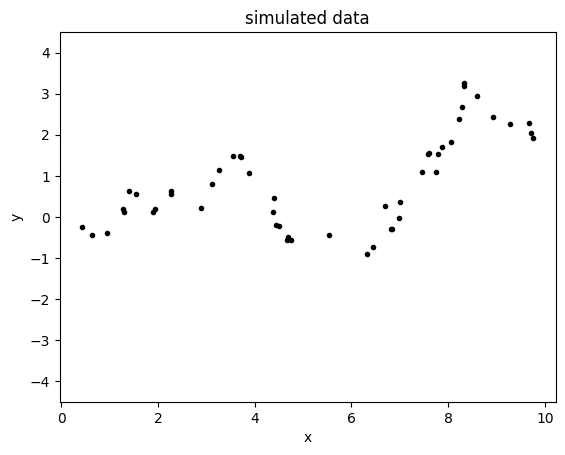

In [39]:
plt.plot(t, y, ".k")
plt.ylim(-4.5, 4.5)
plt.title("simulated data")
plt.xlabel("x")
_ = plt.ylabel("y")

In [40]:
@jax.jit
@jax.value_and_grad
def loss(theta):
    return -build_gp(theta).log_probability(y)

In [41]:
opt = optax.sgd(learning_rate=3e-4)
opt_state = opt.init(params)
for i in range(1000):
    loss_val, grads = loss(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

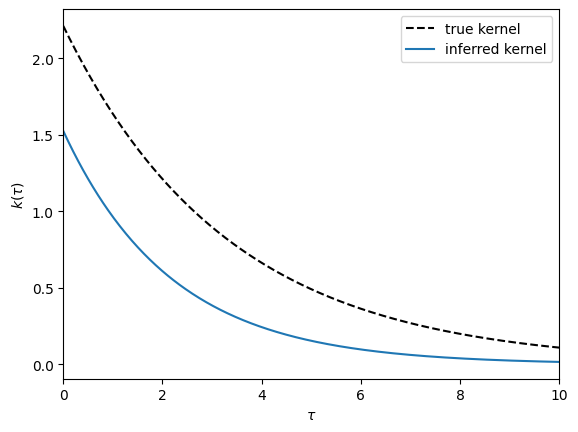

In [43]:
opt_gp = build_gp(params)
tau = np.linspace(0, 10, 500)
plt.plot(tau, true_gp.kernel(tau[:1], tau)[0], "--k", label="true kernel")
plt.plot(tau, opt_gp.kernel(tau[:1], tau)[0], label="inferred kernel")
plt.legend()
plt.xlabel(r"$\tau$")
plt.ylabel(r"$k(\tau)$")
_ = plt.xlim(tau.min(), tau.max())

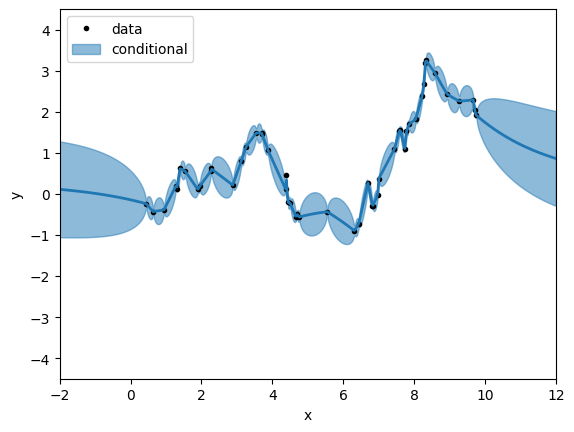

In [44]:
x = np.linspace(-2, 12, 500)
plt.plot(t, y, ".k", label="data")
gp_cond = opt_gp.condition(y, x).gp
mu, var = gp_cond.loc, gp_cond.variance
plt.fill_between(
    x,
    mu + np.sqrt(var),
    mu - np.sqrt(var),
    color="C0",
    alpha=0.5,
    label="conditional",
)
plt.plot(x, mu, color="C0", lw=2)
plt.xlim(x.min(), x.max())
plt.ylim(-4.5, 4.5)
plt.legend(loc=2)
plt.xlabel("x")
_ = plt.ylabel("y")